<a href="https://colab.research.google.com/github/sswaathiii/Data-Analysis/blob/main/Supermart_Grocery_Sales_Retail_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**SUPERMART GROCERY SALES-RETAIL DATA ANALYSIS**

***Logo for Supermart***

Saving Supermart.jpeg to Supermart (1).jpeg


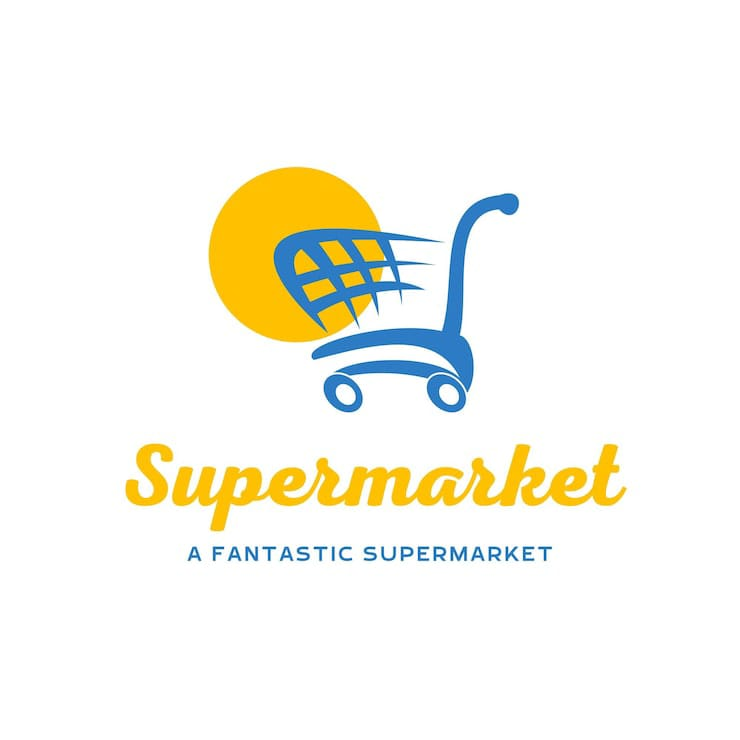

In [ ]:
from google.colab import files
from IPython.display import Image

# This will open a 'Choose File' button
uploaded = files.upload()

# Replace 'your_image.png' with your actual filename
Image('/content/Supermart.jpeg', width=300)

**Data Collection**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random


In [ ]:
pos = [1,2,3,4,5,6,7,8,9,10,11]                                       # POSITION DATASET
runs = [123,64,97,32,10,88,25,76,21,11,2]                             # RUNS DATASET

In [ ]:
data = pd.read_csv('/content/supermarket_grocery_sales-1.csv')


In [ ]:
data.head()

,Invoice_ID,Date,Customer_ID,Customer_Name,Gender,Age,City,Category,Product,Quantity,Unit_Price,Discount,Total_Sales,Payment_Mode,Rating,Profit
0,INV1000,24-01-2024,CUST855,Customer_192,Female,50,Mumbai,Snacks,Biscuits,8,196,0.05,1489.60,UPI,3,140.60
1,INV1001,28-05-2024,CUST696,Customer_122,Female,55,Delhi,Beverages,Soft Drink,3,381,0.05,1085.85,UPI,4,80.98
2,INV1002,18-08-2024,CUST155,Customer_15,Male,63,Hyderabad,Snacks,Chocolate,6,500,0.05,2850.00,UPI,4,40.00
3,INV1003,17-05-2024,CUST396,Customer_221,Female,60,Delhi,Snacks,Biscuits,5,88,0.15,374.00,UPI,2,8.00
4,INV1004,28-04-2024,CUST395,Customer_20,Female,33,Bangalore,Snacks,Biscuits,7,28,0.05,186.20,Cash,1,50.90


In [ ]:
data.shape

In [ ]:
data.index


RangeIndex(start=0, stop=300, step=1)

In [ ]:
data.columns


Index(['Invoice_ID', 'Date', 'Customer_ID', 'Customer_Name', 'Gender', 'Age',
       'City', 'Category', 'Product', 'Quantity', 'Unit_Price', 'Discount',
       'Total_Sales', 'Payment_Mode', 'Rating', 'Profit'],
      dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Invoice_ID     300 non-null    object 
 1   Date           300 non-null    object 
 2   Customer_ID    300 non-null    object 
 3   Customer_Name  300 non-null    object 
 4   Gender         300 non-null    object 
 5   Age            300 non-null    int64  
 6   City           300 non-null    object 
 7   Category       300 non-null    object 
 8   Product        300 non-null    object 
 9   Quantity       300 non-null    int64  
 10  Unit_Price     300 non-null    int64  
 11  Discount       300 non-null    float64
 12  Total_Sales    300 non-null    float64
 13  Payment_Mode   300 non-null    object 
 14  Rating         300 non-null    int64  
 15  Profit         300 non-null    float64
dtypes: float64(3), int64(4), object(9)
memory usage: 37.6+ KB


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for plots
sns.set_style('whitegrid')

In [ ]:
# Load the dataset
raw_df = pd.read_csv('/content/supermarket_grocery_sales-1.csv')

# Create a working copy
df = raw_df.copy()



**Feature Engineering**


In [ ]:
# Extract time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.strftime('%B')
df['Day_of_Week'] = df['Date'].dt.day_name()

# Calculate Profit Margin percentage
df['Profit Margin (%)'] = (df['Profit'] / df['Total_Sales']) * 100


**Average Profit**

In [ ]:
# Top 5 Categories by Total Sales
top_categories = df.groupby('Category')['Total_Sales'].sum().sort_values(ascending=False).head(5)

# Average Profit by Region
regional_profit = df.groupby('City')['Profit'].mean()

print("Top Categories:\n", top_categories)


Top Categories:
 Category
Dairy                  88564.95
Beverages              87277.45
Fruits & Vegetables    80903.25
Snacks                 79679.15
Household              70522.55
Name: Total_Sales, dtype: float64


**Exploratory Data Analysis (EDA)**


/tmp/ipython-input-3093477723.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.index, y=top_categories.values, palette='viridis')


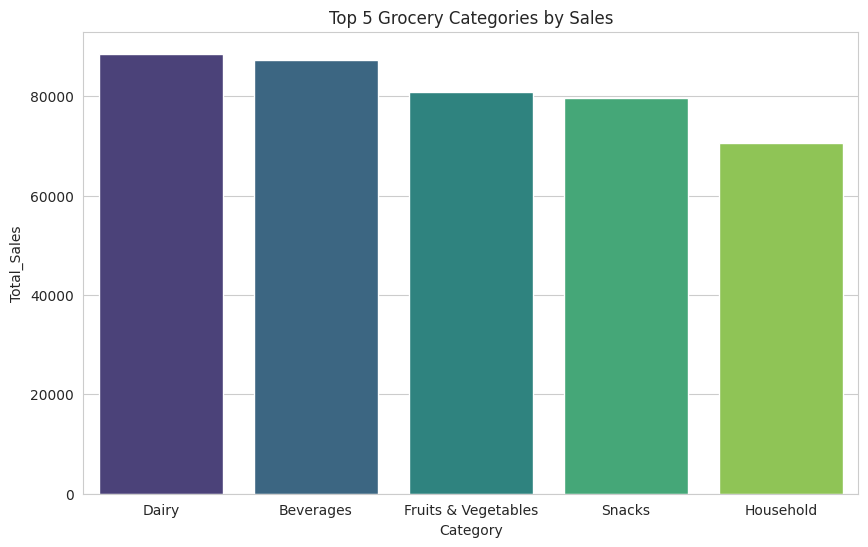

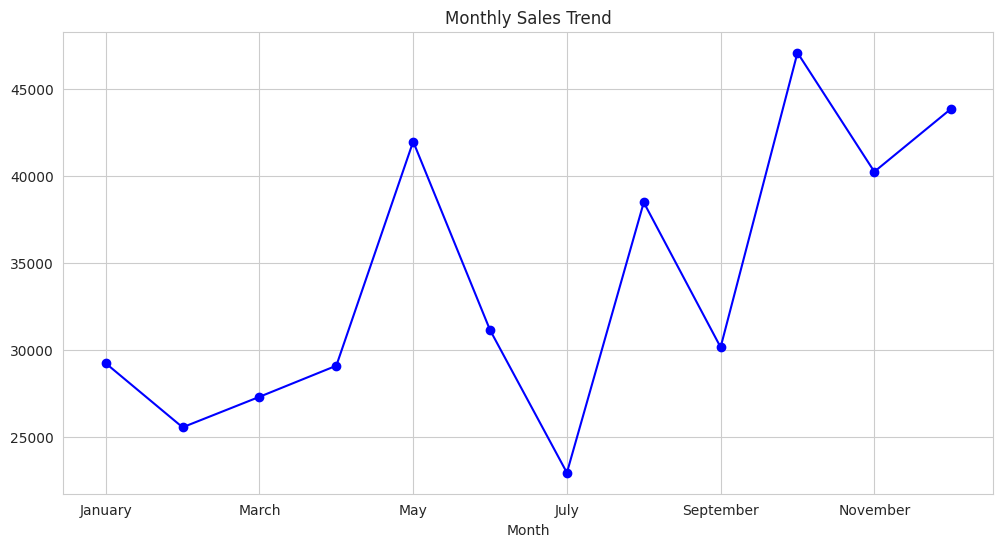

In [ ]:
# Visualize Sales by Category
plt.figure(figsize=(10, 6))
sns.barplot(x=top_categories.index, y=top_categories.values, palette='viridis')
plt.title('Top 5 Grocery Categories by Sales')
plt.ylabel('Total_Sales')
plt.show()

# Visualize Monthly Sales Trends
monthly_sales = df.groupby('Month')['Total_Sales'].sum().reindex(['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'])
plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='line', marker='o', color='blue')
plt.title('Monthly Sales Trend')
plt.show()


 **Train a Linear Regression Model**





In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Encode categorical columns
le = LabelEncoder()
df['Category'] = le.fit_transform(df['Category'])
df['City'] = le.fit_transform(df['City'])

# Define Features (Predictors) and Target (Sales)
X = df[['Category', 'City', 'Profit', 'Discount']]
y = df['Total_Sales']


In [ ]:
# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# View the impact of each feature
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


Coefficients: [  -26.94030233    17.04363095     4.89831348 -3074.49783233]
Intercept: 1249.1936670141997


In [ ]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluate model performance
print(f"R-squared: {r2_score(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")


R-squared: 0.00
MSE: 1197840.01


**Simple Demand Prediction**

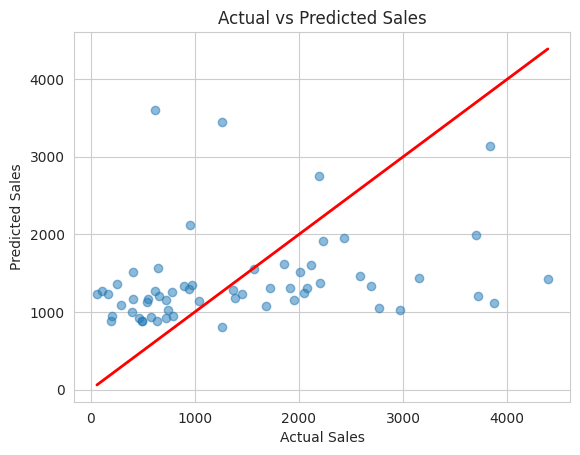

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()


**Sales Distribution by Category**

/tmp/ipython-input-641663295.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Total_Sales', data=data, palette='Set2')


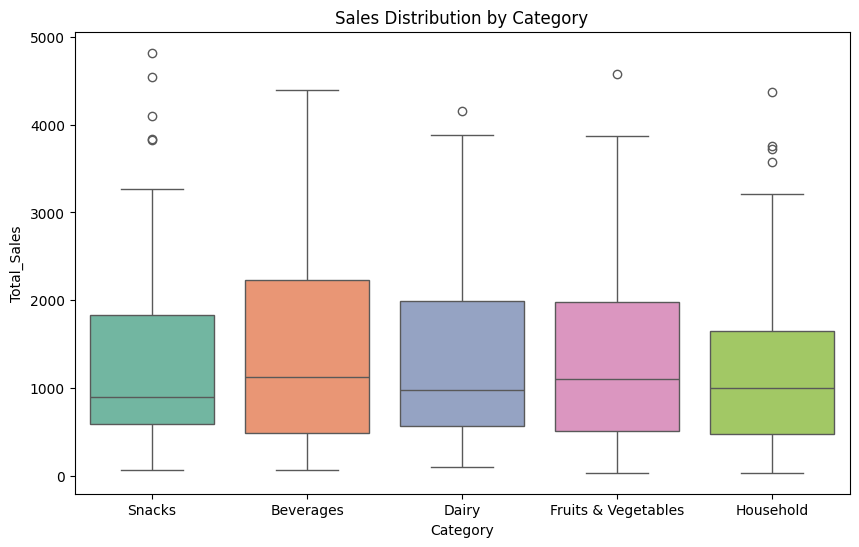

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Total_Sales', data=data, palette='Set2')
plt.title('Sales Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Total_Sales')
plt.show()

**Total Sales Over Time**

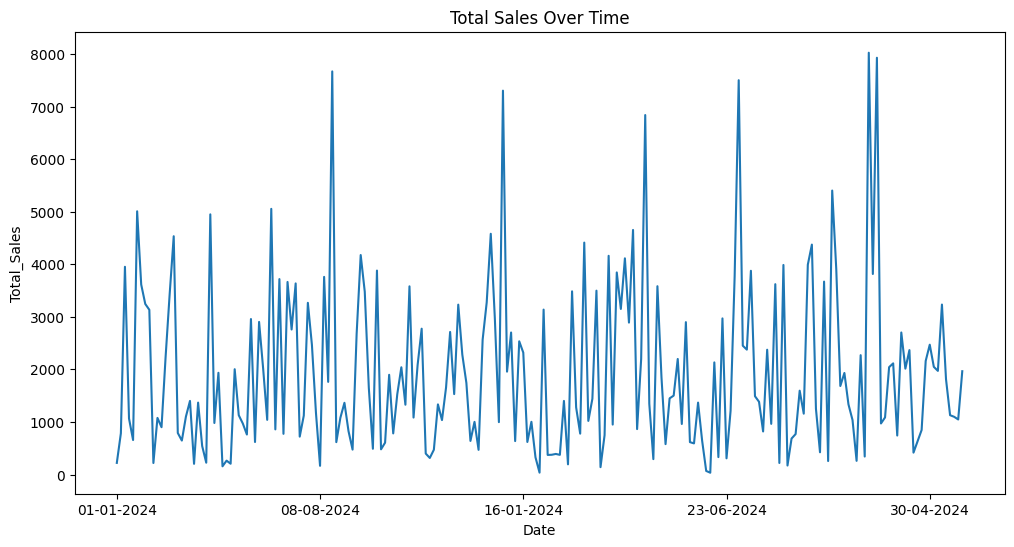

In [ ]:
plt.figure(figsize=(12, 6))
data.groupby('Date')['Total_Sales'].sum().plot()
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total_Sales')
plt.show()

**Histogram of Unit_Price**

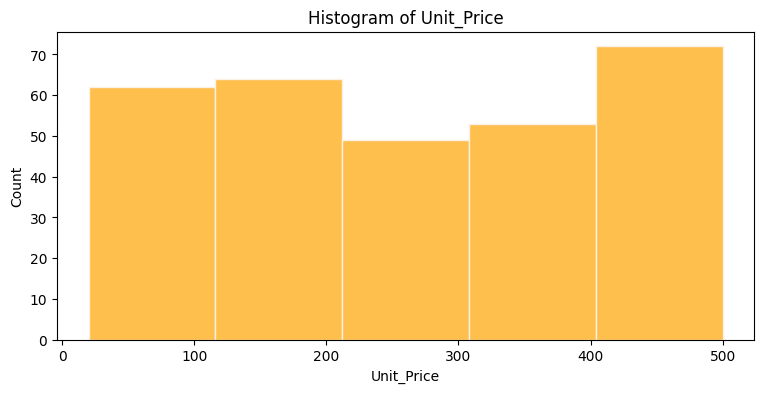

In [ ]:
plt.figure(figsize = (9,4))

sns.histplot(data = data ,x = 'Unit_Price', color = 'Orange',
             edgecolor = 'linen', alpha = 0.7, bins = 5)

plt.title("Histogram of Unit_Price")
plt.xlabel('Unit_Price')
plt.ylabel('Count')
plt.show()

In [ ]:
round(data['Unit_Price'].mean(),2)

np.float64(265.09)

In [ ]:

data['Unit_Price'].median()

275.0

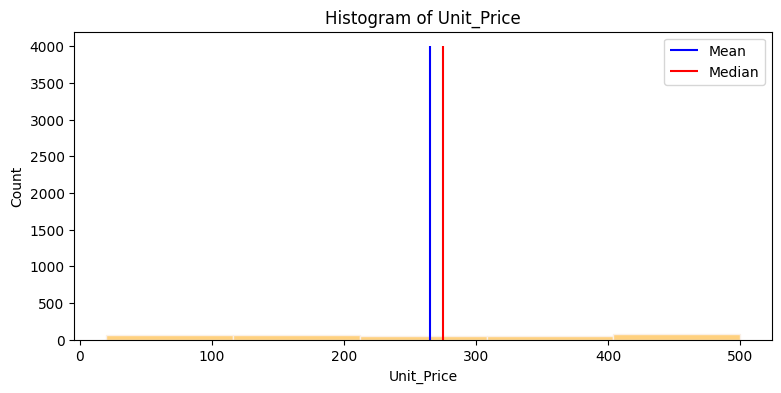

In [ ]:
plt.figure(figsize = (9,4))

sns.histplot(data = data ,x = 'Unit_Price', color = 'orange',
             edgecolor = 'linen', alpha = 0.5, bins = 5)

plt.title("Histogram of Unit_Price" )
plt.xlabel('Unit_Price')
plt.ylabel('Count')
plt.vlines(data['Unit_Price'].mean(), ymin = 0, ymax = 4000, colors='blue', label='Mean')
plt.vlines(data['Unit_Price'].median(), ymin = 0, ymax = 4000, colors='red', label='Median')
plt.legend()
plt.show()


**Count Plot of Rating**

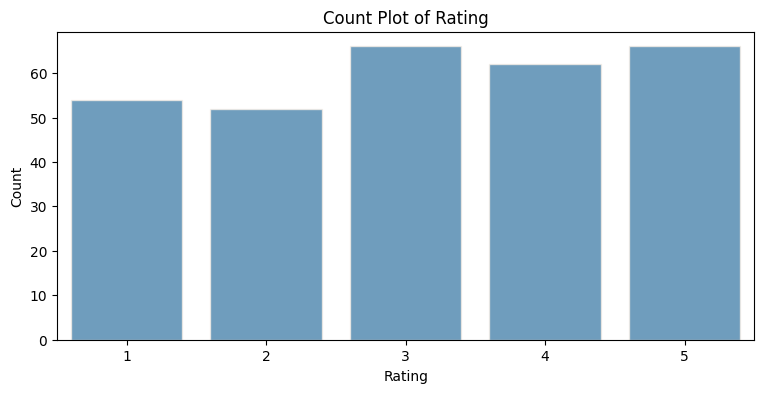

In [ ]:
plt.figure(figsize = (9,4))

sns.countplot(data = data ,x = 'Rating', edgecolor = 'linen', alpha = 0.7)

plt.title("Count Plot of Rating")
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

**Scatterplot of Discount v/s Profit**

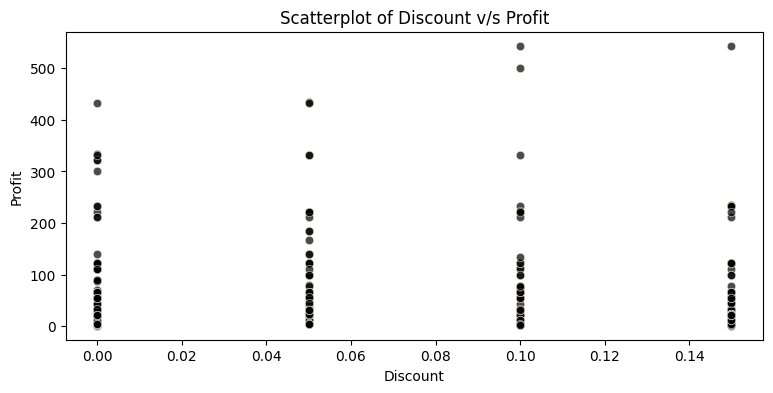

In [ ]:
plt.figure(figsize = (9,4))

sns.scatterplot(data = data ,x = 'Discount', y = 'Profit', color = 'k',
             edgecolor = 'linen', alpha = 0.7)

plt.title("Scatterplot of Discount v/s Profit")
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

**Histogram of Profit**

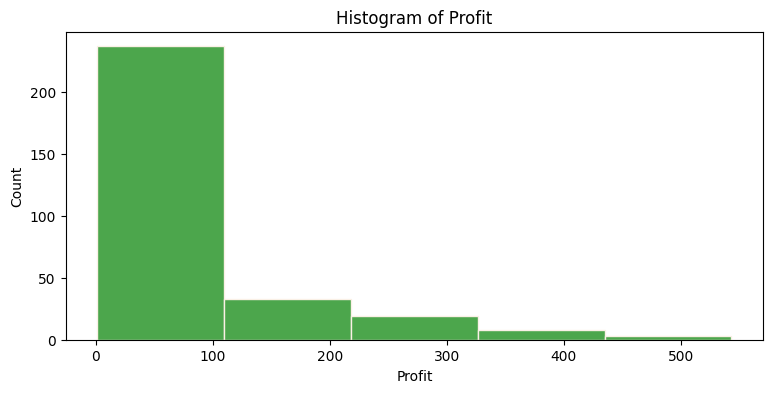

In [ ]:
plt.figure(figsize = (9,4))

sns.histplot(data = data ,x = 'Profit', color = 'green',
             edgecolor = 'linen', alpha = 0.7, bins = 5)

plt.title("Histogram of Profit")
plt.xlabel('Profit')
plt.ylabel('Count')
plt.show()


**Distplot of Profit**

/tmp/ipython-input-2277383827.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Profit'], color = 'blue')


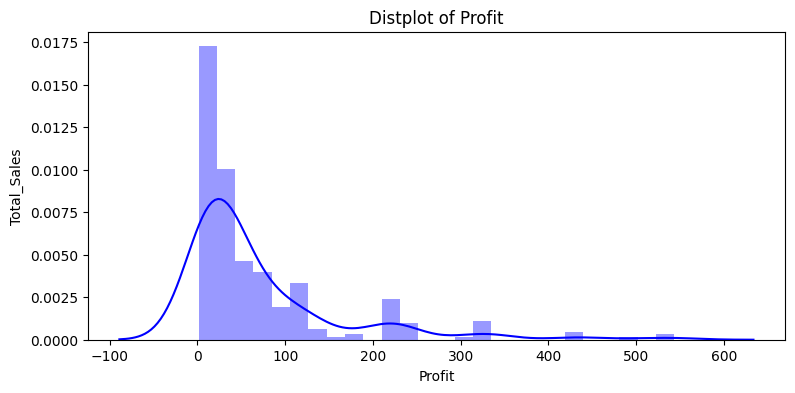

In [ ]:
plt.figure(figsize = (9,4))

sns.distplot(data['Profit'], color = 'blue')

plt.title("Distplot of Profit")
plt.xlabel('Profit')
plt.ylabel('Total_Sales')
plt.show()

In [ ]:
data['Profit'].skew()


np.float64(2.5094554513549387)

In [ ]:

data['Profit'].mean()

In [ ]:
data['Profit'].median()

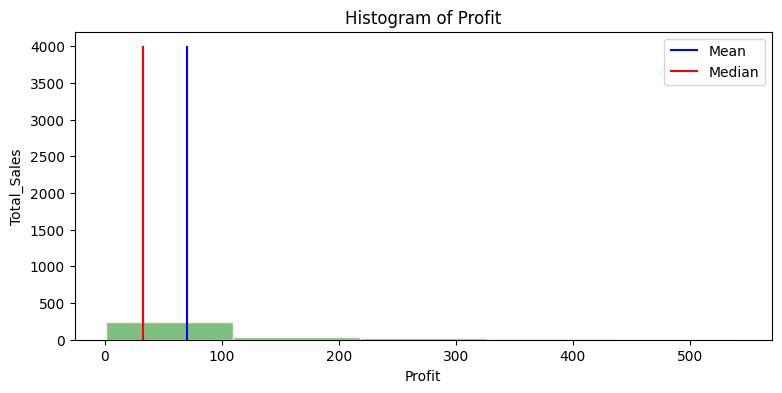

In [ ]:
plt.figure(figsize = (9,4))

sns.histplot(data = data ,x = 'Profit', color = 'green',
             edgecolor = 'linen', alpha = 0.5, bins = 5)

plt.title("Histogram of Profit")
plt.xlabel('Profit')
plt.ylabel('Total_Sales')
plt.vlines(data['Profit'].mean(), ymin = 0, ymax = 4000, colors='blue', label='Mean')
plt.vlines(data['Profit'].median(), ymin = 0, ymax = 4000, colors='red', label='Median')
plt.legend()
plt.show()


**Histogram of Total_Sales**

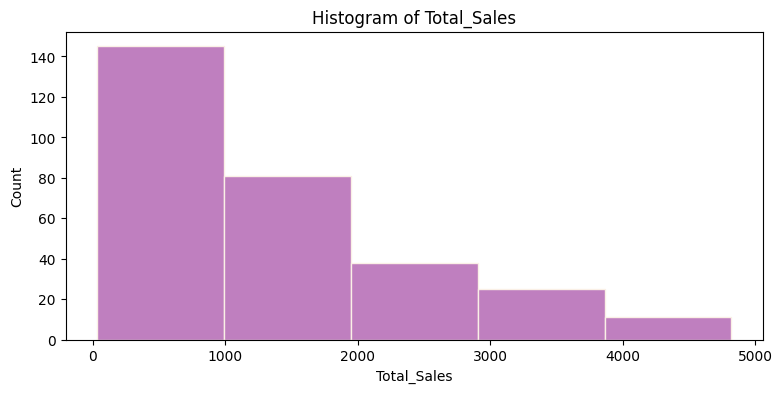

In [ ]:
plt.figure(figsize = (9,4))

sns.histplot(data = data ,x = 'Total_Sales', color = 'Purple',
             edgecolor = 'linen', alpha = 0.5, bins = 5)

plt.title("Histogram of Total_Sales")
plt.xlabel('Total_Sales')
plt.ylabel('Count')
plt.show()


In [ ]:
data['Total_Sales'].mean()

np.float64(1356.4911666666667)

In [ ]:
data['Total_Sales'].median()

1018.725

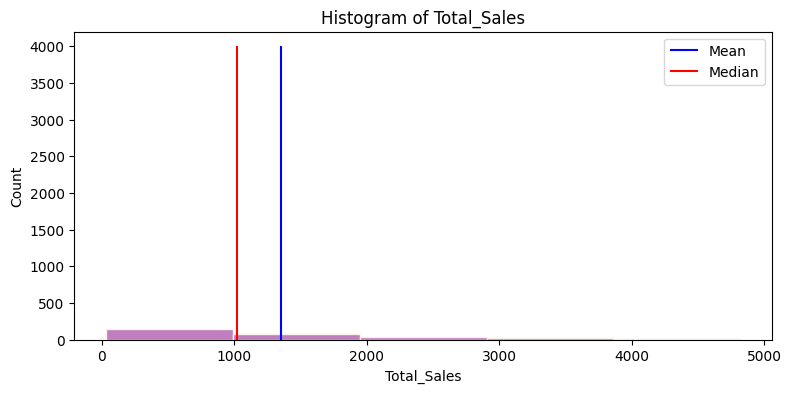

In [ ]:
plt.figure(figsize = (9,4))

sns.histplot(data = data ,x = 'Total_Sales', color = 'Purple',
             edgecolor = 'linen', alpha = 0.5, bins = 5)

plt.title("Histogram of Total_Sales")
plt.xlabel('Total_Sales')
plt.ylabel('Count')
plt.vlines(data['Total_Sales'].mean(), ymin = 0, ymax = 4000, colors='blue', label='Mean')
plt.vlines(data['Total_Sales'].median(), ymin = 0, ymax = 4000, colors='red', label='Median')
plt.legend()
plt.show()


**Distplot of Total_Sales**

/tmp/ipython-input-1659214267.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Total_Sales'], color = 'blue')


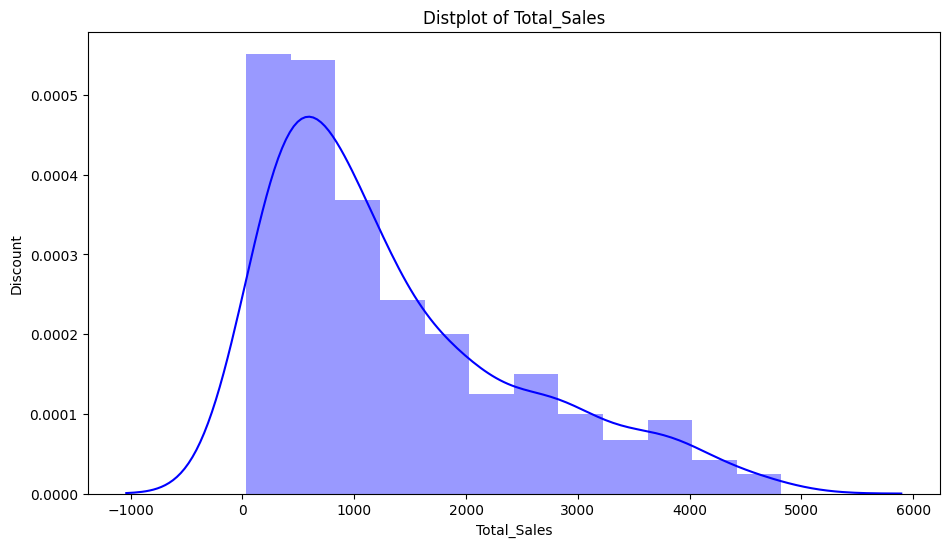

In [ ]:
plt.figure(figsize = (11,6))

sns.distplot(data['Total_Sales'], color = 'blue')

plt.title("Distplot of Total_Sales")
plt.xlabel('Total_Sales')
plt.ylabel('Discount')
plt.show()


**Bar Plot of Quantity**

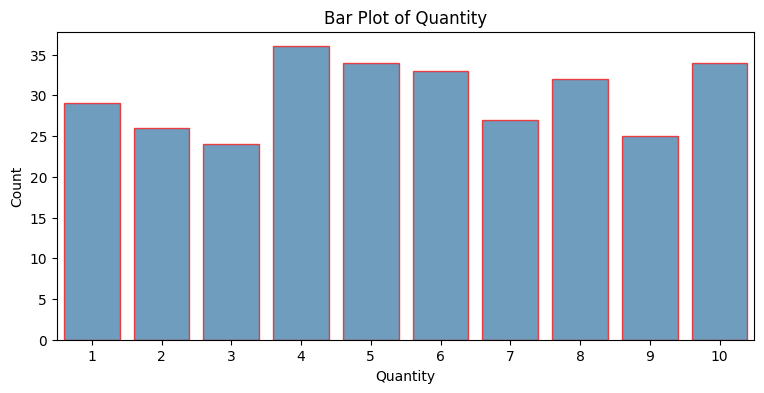

In [ ]:

plt.figure(figsize = (9,4))

sns.countplot(data = data ,x = 'Quantity', edgecolor = 'Red', alpha = 0.7)

plt.title("Bar Plot of Quantity")
plt.xlabel('Quantity')
plt.ylabel('Count')
plt.show()

**New Pandas Series that contains the details of data**

In [ ]:
rep_data = pd.DataFrame(index = ['Unit_Price','Profit','Total_Sales','Quantity'],
                     data = [data['Unit_Price'].mean(),data['Profit'].mean(),
                             data['Total_Sales'].mean(),data['Quantity'].value_counts().index[0]])

In [ ]:
rep_data

,0
Unit_Price,265.093333
Profit,70.455473
Total_Sales,1356.491167
Quantity,4.000000


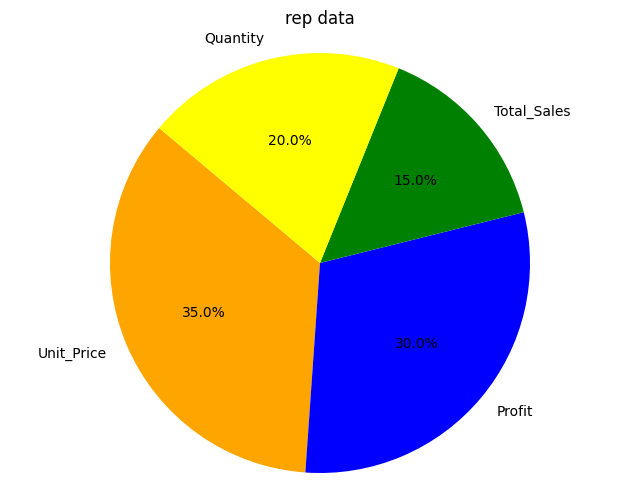

In [ ]:
import matplotlib.pyplot as plt
labels=['Unit_Price','Profit','Total_Sales','Quantity']
sizes=[35,30,15,20]
colors=['Orange','Blue','Green','Yellow']

plt.figure(figsize=(8,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)

plt.title("rep data")
plt.axis('equal')
plt.show()